<a href="https://colab.research.google.com/github/marziqhaqkim-dotcom/ai_course_exercises/blob/main/ServiceRequestRedo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data from Google Drive

First, we need to mount Google Drive to access your files.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Once your Google Drive is mounted, you can load your data. Here's an example of how to load a CSV file. You'll need to replace `'path/to/your/file.csv'` with the actual path to your file in Google Drive (e.g., `'/content/drive/MyDrive/my_data.csv'`).

In [4]:
import pandas as pd

file_path = '/content/drive/MyDrive/Google Colab/service_alerts_2024 (1).parquet'

try:
    df = pd.read_parquet(file_path)
    print("Data loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file at '{file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Data loaded successfully!


,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp
0,14050001656394124,2024-01-06 05:06:14,2024-01-06 05:08:13,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001701003,2024-01-06 05:07:02.489510,20240106,None
1,14050001656394176,2024-01-06 05:06:47,2024-01-06 05:08:44,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001003481001,2024-01-06 05:07:02.489510,20240106,None
2,14050001656394207,2024-01-06 05:06:56,2024-01-06 05:08:55,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001551001,2024-01-06 05:08:02.602139,20240106,None
3,14050001656394246,2024-01-06 05:07:09,2024-01-06 05:09:08,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001831002,2024-01-06 05:08:02.602139,20240106,None
4,14050001656394262,2024-01-06 05:07:34,2024-01-06 05:09:34,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001002121002,2024-01-06 05:08:02.602139,20240106,None


## Filter Data by Stop ID

Filtering the DataFrame to keep rows where `stop_id` matches the specified number.

In [7]:
target_stop_id = 90110010004 # Convert the target value to an integer
filtered_df = df[df['stop_id'] == target_stop_id]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape: {filtered_df.shape}")

display(filtered_df.head())

Original DataFrame shape: (1972779, 13)
Filtered DataFrame shape: (0, 13)


,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp


## Filtering for a New Stop ID

Let's try filtering the DataFrame `df` with the newly provided `stop_id`.

In [8]:
new_target_stop_id = 9011001000400000 # The new stop_id to search for

filtered_df_new = df[df['stop_id'] == new_target_stop_id]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape with new stop_id: {filtered_df_new.shape}")

display(filtered_df_new.head())

Original DataFrame shape: (1972779, 13)
Filtered DataFrame shape with new stop_id: (0, 13)


,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp


## Searching Across All Columns

Since the specific `stop_id` was not found, let's search the entire DataFrame for the number `9011001000400000` in any column, considering both its integer and string representations.

In [9]:
target_value_int = 9011001000400000
target_value_str = str(target_value_int)

# Create a boolean mask for rows where the target value is found in any column
mask = False
for column in df.columns:
    # Check for integer match in numeric columns
    if pd.api.types.is_numeric_dtype(df[column]):
        mask |= (df[column] == target_value_int)
    # Check for string containment in object/string columns
    elif pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_string_dtype(df[column]):
        mask |= df[column].astype(str).str.contains(target_value_str, na=False)

# Filter the DataFrame using the combined mask
found_rows_df = df[mask]

print(f"Number of rows found containing '{target_value_int}': {len(found_rows_df)}")
if not found_rows_df.empty:
    print("Rows found:")
    display(found_rows_df)
else:
    print(f"The number '{target_value_int}' was not found in any column of the DataFrame.")

Number of rows found containing '9011001000400000': 9
Rows found:


,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp
313154,14050001674290118,2024-02-19 18:42:35,2024-02-19 19:41:00,3,Tekniska fel på skyltning på bussarna,För närvarande är det tekniska problem med sky...,9011001000400000,-1,-1,-1,2024-02-19 18:44:03.045229,20240219,None
313165,14050001674293018,2024-02-19 18:44:37,2024-02-19 20:00:00,3,Tekniska fel på skyltning på bussarna,För närvarande är det tekniska problem med sky...,9011001000400000,-1,-1,-1,2024-02-19 18:46:02.809764,20240219,None
313178,14050001674296296,2024-02-19 18:47:41,2024-02-19 20:00:00,3,Tekniska fel på skyltning på bussarna,För närvarande är det tekniska problem med sky...,9011001000400000,-1,-1,-1,2024-02-19 18:49:01.916490,20240219,None
401681,14050001684965837,2024-03-31 10:40:00,2024-03-31 14:30:00,2,Hållplats indragen pga. supportermarsch.,Hållplats indragen pga. supportermarsch.,9011001000400000,-1,-1,9021001010136000,2024-03-31 10:41:02.167860,20240331,None
401682,14050001684965837,2024-03-31 10:40:00,2024-03-31 14:30:00,2,Hållplats indragen pga. supportermarsch.,Hållplats indragen pga. supportermarsch.,9011001000400000,-1,-1,9021001010401000,2024-03-31 10:41:02.167860,20240331,None
401683,14050001684965837,2024-03-31 10:40:00,2024-03-31 14:30:00,2,Hållplats indragen pga. supportermarsch.,Hållplats indragen pga. supportermarsch.,9011001000400000,-1,-1,9021001010261000,2024-03-31 10:41:02.167860,20240331,None
401684,14050001684965837,2024-03-31 10:40:00,2024-03-31 14:30:00,2,Hållplats indragen pga. supportermarsch.,Hållplats indragen pga. supportermarsch.,9011001000400000,-1,-1,9021001011725000,2024-03-31 10:41:02.167860,20240331,None
553982,14050001690562069,2024-04-06 15:28:03,2024-04-06 18:00:00,2,Oregelbunden trafik,Oregelbunden trafik med förseningar upp till 2...,9011001000400000,-1,-1,-1,2024-04-06 15:29:02.700187,20240406,None
1529968,14050001746592167,2024-10-14 09:20:50,2024-10-14 10:30:00,11,Oregelbunden trafik,Oregelbunden trafik med förseningar upp till 2...,9011001000400000,-1,-1,-1,2024-10-14 09:22:03.037887,20241014,None


## Search for a specific digit at a specific position within columns

Now, let's find rows where any column contains a '4' at the 10th digit position. We will consider values as strings to perform this check.

In [10]:
target_digit = '4'
target_position = 9 # 10th digit means index 9 in a 0-indexed string

rows_with_digit_at_position = pd.DataFrame()

# Initialize a combined mask
combined_mask = pd.Series(False, index=df.index)

for column_name in df.columns:
    # Convert column to string type for uniform processing
    # Use .astype(str) to handle both numeric and object types consistently
    string_column = df[column_name].astype(str)

    # Create a mask for values where the string length is at least the target_position + 1
    # and the character at target_position is the target_digit
    column_mask = (
        string_column.str.len() > target_position
    ) & (
        string_column.str[target_position] == target_digit
    )

    # Update the combined mask with results from the current column
    combined_mask |= column_mask

# Filter the DataFrame using the combined mask
rows_with_digit_at_position = df[combined_mask]

print(f"Number of rows found containing '{target_digit}' at the {target_position + 1}th position in any column: {len(rows_with_digit_at_position)}")

if not rows_with_digit_at_position.empty:
    print("Rows found:")
    display(rows_with_digit_at_position)
else:
    print(f"No rows found containing '{target_digit}' at the {target_position + 1}th position in any column.")

Number of rows found containing '4' at the 10th position in any column: 668979
Rows found:


,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp
132,14050001654532686,2024-01-01 14:00:42,2024-01-01 14:47:00,3,Inställd delsträcka,Inställd delsträcka,-1,14010000643743141,0,9022001002301002,2024-01-01 14:01:02.626936,20240101,None
133,14050001654532686,2024-01-01 14:00:42,2024-01-01 14:47:00,3,Inställd delsträcka,Inställd delsträcka,-1,14010000643743141,0,9022001002251002,2024-01-01 14:01:02.626936,20240101,None
134,14050001654532686,2024-01-01 14:00:42,2024-01-01 14:47:00,3,Inställd delsträcka,Inställd delsträcka,-1,14010000643743141,0,9022001002241002,2024-01-01 14:01:02.626936,20240101,None
135,14050001654532686,2024-01-01 14:00:42,2024-01-01 14:47:00,3,Inställd delsträcka,Inställd delsträcka,-1,14010000643743141,0,9022001002231002,2024-01-01 14:01:02.626936,20240101,None
147,14050001655704801,2024-01-04 15:13:01,2024-01-04 17:17:00,2,Invänta tid,Invänta tid,-1,14010000653155844,0,9022001006251002,2024-01-04 15:14:01.889669,20240104,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1972689,14050001771194429,2024-12-31 23:32:02,2025-01-01 00:11:00,2,Inställd avgång,Henriksdalsberget kl 23:27 till Tjärhovsplan ä...,-1,14010000643936486,0,9022001010591005,2024-12-31 23:33:02.521284,20241231,None
1972690,14050001771194429,2024-12-31 23:32:02,2025-01-01 00:11:00,2,Inställd avgång,Henriksdalsberget kl 23:27 till Tjärhovsplan ä...,-1,14010000643936486,0,9022001010592001,2024-12-31 23:33:02.521284,20241231,None
1972691,14050001771194429,2024-12-31 23:32:02,2025-01-01 00:11:00,2,Inställd avgång,Henriksdalsberget kl 23:27 till Tjärhovsplan ä...,-1,14010000643936486,0,9022001010254003,2024-12-31 23:33:02.521284,20241231,None
1972692,14050001771194429,2024-12-31 23:32:02,2025-01-01 00:11:00,2,Inställd avgång,Henriksdalsberget kl 23:27 till Tjärhovsplan ä...,-1,14010000643936486,0,9022001010250001,2024-12-31 23:33:02.521284,20241231,None


## Summary of 'cause' column for filtered rows

Let's summarize the 'cause' column for the `rows_with_digit_at_position` DataFrame.

In [13]:
# Group by 'cause' column and count occurrences
cause_summary = rows_with_digit_at_position['cause'].value_counts().reset_index()
cause_summary.columns = ['Cause', 'Count']

print("Summary of 'cause' column for rows where '4' is at the 10th position in any column:")
display(cause_summary)

Summary of 'cause' column for rows where '4' is at the 10th position in any column:


,Cause,Count
0,2,545980
1,3,105837
2,11,9437
3,12,3067
4,9,2604
5,6,1614
6,8,327
7,10,113


In [15]:
display(rows_with_digit_at_position.head())

,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp
132,14050001654532686,2024-01-01 14:00:42,2024-01-01 14:47:00,3,Inställd delsträcka,Inställd delsträcka,-1,14010000643743141,0,9022001002301002,2024-01-01 14:01:02.626936,20240101,None
133,14050001654532686,2024-01-01 14:00:42,2024-01-01 14:47:00,3,Inställd delsträcka,Inställd delsträcka,-1,14010000643743141,0,9022001002251002,2024-01-01 14:01:02.626936,20240101,None
134,14050001654532686,2024-01-01 14:00:42,2024-01-01 14:47:00,3,Inställd delsträcka,Inställd delsträcka,-1,14010000643743141,0,9022001002241002,2024-01-01 14:01:02.626936,20240101,None
135,14050001654532686,2024-01-01 14:00:42,2024-01-01 14:47:00,3,Inställd delsträcka,Inställd delsträcka,-1,14010000643743141,0,9022001002231002,2024-01-01 14:01:02.626936,20240101,None
147,14050001655704801,2024-01-04 15:13:01,2024-01-04 17:17:00,2,Invänta tid,Invänta tid,-1,14010000653155844,0,9022001006251002,2024-01-04 15:14:01.889669,20240104,None


In [16]:
display(found_rows_df['route_id'])

,route_id
313154,9011001000400000
313165,9011001000400000
313178,9011001000400000
401681,9011001000400000
401682,9011001000400000
401683,9011001000400000
401684,9011001000400000
553982,9011001000400000
1529968,9011001000400000


In [17]:
display(found_rows_df.iloc[[3]])

,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp
401681,14050001684965837,2024-03-31 10:40:00,2024-03-31 14:30:00,2,Hållplats indragen pga. supportermarsch.,Hållplats indragen pga. supportermarsch.,9011001000400000,-1,-1,9021001010136000,2024-03-31 10:41:02.167860,20240331,None


In [18]:
display(found_rows_df)

,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp
313154,14050001674290118,2024-02-19 18:42:35,2024-02-19 19:41:00,3,Tekniska fel på skyltning på bussarna,För närvarande är det tekniska problem med sky...,9011001000400000,-1,-1,-1,2024-02-19 18:44:03.045229,20240219,None
313165,14050001674293018,2024-02-19 18:44:37,2024-02-19 20:00:00,3,Tekniska fel på skyltning på bussarna,För närvarande är det tekniska problem med sky...,9011001000400000,-1,-1,-1,2024-02-19 18:46:02.809764,20240219,None
313178,14050001674296296,2024-02-19 18:47:41,2024-02-19 20:00:00,3,Tekniska fel på skyltning på bussarna,För närvarande är det tekniska problem med sky...,9011001000400000,-1,-1,-1,2024-02-19 18:49:01.916490,20240219,None
401681,14050001684965837,2024-03-31 10:40:00,2024-03-31 14:30:00,2,Hållplats indragen pga. supportermarsch.,Hållplats indragen pga. supportermarsch.,9011001000400000,-1,-1,9021001010136000,2024-03-31 10:41:02.167860,20240331,None
401682,14050001684965837,2024-03-31 10:40:00,2024-03-31 14:30:00,2,Hållplats indragen pga. supportermarsch.,Hållplats indragen pga. supportermarsch.,9011001000400000,-1,-1,9021001010401000,2024-03-31 10:41:02.167860,20240331,None
401683,14050001684965837,2024-03-31 10:40:00,2024-03-31 14:30:00,2,Hållplats indragen pga. supportermarsch.,Hållplats indragen pga. supportermarsch.,9011001000400000,-1,-1,9021001010261000,2024-03-31 10:41:02.167860,20240331,None
401684,14050001684965837,2024-03-31 10:40:00,2024-03-31 14:30:00,2,Hållplats indragen pga. supportermarsch.,Hållplats indragen pga. supportermarsch.,9011001000400000,-1,-1,9021001011725000,2024-03-31 10:41:02.167860,20240331,None
553982,14050001690562069,2024-04-06 15:28:03,2024-04-06 18:00:00,2,Oregelbunden trafik,Oregelbunden trafik med förseningar upp till 2...,9011001000400000,-1,-1,-1,2024-04-06 15:29:02.700187,20240406,None
1529968,14050001746592167,2024-10-14 09:20:50,2024-10-14 10:30:00,11,Oregelbunden trafik,Oregelbunden trafik med förseningar upp till 2...,9011001000400000,-1,-1,-1,2024-10-14 09:22:03.037887,20241014,None


## Count rows with '4' at the 10th position in 'stop_id' column

Let's specifically count rows where the `stop_id` column contains the digit '4' at its 10th position.

In [12]:
target_digit = '4'
target_position = 9 # 10th digit means index 9 in a 0-indexed string

# Ensure 'stop_id' is treated as string for this operation
stop_id_as_str = df['stop_id'].astype(str)

# Create a mask for values where:
# 1. The string length is at least target_position + 1 (i.e., 10 characters or more)
# 2. The character at target_position (index 9) is the target_digit ('4')
mask_stop_id_specific = (
    stop_id_as_str.str.len() > target_position
) & (
    stop_id_as_str.str[target_position] == target_digit
)

# Count the number of rows that satisfy this condition
rows_count_specific = mask_stop_id_specific.sum()

print(f"Number of rows where 'stop_id' has '{target_digit}' at the {target_position + 1}th position: {rows_count_specific}")

Number of rows where 'stop_id' has '4' at the 10th position: 106462


## Inspecting `stop_id` Column

Let's check the data type and some unique values of the `stop_id` column to debug the filtering issue.

In [11]:
print(f"Data type of 'stop_id' column: {df['stop_id'].dtype}")
print("First 10 unique values of 'stop_id' column:")
display(df['stop_id'].unique()[:10])

Data type of 'stop_id' column: int64
First 10 unique values of 'stop_id' column:


array([9022001001701003, 9022001003481001, 9022001001551001,
       9022001001831002, 9022001002121002, 9022001002601003,
       9022001001931002, 9022001002111002, 9022001002531001,
       9022001006781001])

In [19]:
df['route_id'] = pd.to_numeric(df['route_id'], errors='coerce').astype('Int64') # Use 'Int64' to allow for pandas nullable integer type
print("Data type of 'route_id' column after conversion:")
display(df['route_id'].dtype)
print("First 10 unique values of 'route_id' column after conversion:")
display(df['route_id'].unique()[:10])

Data type of 'route_id' column after conversion:


Int64Dtype()

First 10 unique values of 'route_id' column after conversion:


<IntegerArray>
[              -1, 9011001044100000, 9011001042100000, 9011001041700000,
 9011001070900000, 9011001043900000, 9011001043000000,             <NA>,
 9011001002100000, 9011001096100000]
Length: 10, dtype: Int64

In [20]:
df['route_id'] = pd.to_numeric(df['route_id'], errors='coerce').astype('Int64') # Use 'Int64' to allow for pandas nullable integer type
print("Data type of 'route_id' column after conversion:")
display(df['route_id'].dtype)
print("First 10 unique values of 'route_id' column after conversion:")
display(df['route_id'].unique()[:10])

Data type of 'route_id' column after conversion:


Int64Dtype()

First 10 unique values of 'route_id' column after conversion:


<IntegerArray>
[              -1, 9011001044100000, 9011001042100000, 9011001041700000,
 9011001070900000, 9011001043900000, 9011001043000000,             <NA>,
 9011001002100000, 9011001096100000]
Length: 10, dtype: Int64

In [21]:
target_route_id = 9011001000400000
rows_with_target_route_id = df[df['route_id'] == target_route_id]

print(f"Number of rows where 'route_id' is {target_route_id}: {len(rows_with_target_route_id)}")


Number of rows where 'route_id' is 9011001000400000: 9


In [22]:
cause_of_delay_for_route = rows_with_target_route_id['cause'].value_counts().reset_index()
cause_of_delay_for_route.columns = ['Cause', 'Count']

print(f"Cause of delay for route_id 9011001000400000:")
display(cause_of_delay_for_route)

Cause of delay for route_id 9011001000400000:


,Cause,Count
0,2,5
1,3,3
2,11,1


In [1]:
description_by_cause = rows_with_target_route_id.groupby('cause')['description_text2'].apply(lambda x: x.unique().tolist())

print(f"Description text for each cause of route_id {target_route_id}:")
display(description_by_cause)

NameError: name 'rows_with_target_route_id' is not defined

In [2]:
print(f"Specific description_text2 for each cause of route_id {target_route_id}:")
display(description_by_cause)

NameError: name 'target_route_id' is not defined

In [3]:
target_route_id = 9011001000400000
rows_with_target_route_id = df[df['route_id'] == target_route_id]

description_by_cause = rows_with_target_route_id.groupby('cause')['description_text2'].apply(lambda x: x.unique().tolist())

print(f"Description text for each cause of route_id {target_route_id}:")
display(description_by_cause)

NameError: name 'df' is not defined

In [7]:
import pandas as pd

file_path = '/content/drive/MyDrive/service_alerts_2024.parquet'

try:
    df = pd.read_parquet(file_path)
    print("Data loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file at '{file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Data loaded successfully!


,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp
0,14050001656394124,2024-01-06 05:06:14,2024-01-06 05:08:13,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001701003,2024-01-06 05:07:02.489510,20240106,None
1,14050001656394176,2024-01-06 05:06:47,2024-01-06 05:08:44,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001003481001,2024-01-06 05:07:02.489510,20240106,None
2,14050001656394207,2024-01-06 05:06:56,2024-01-06 05:08:55,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001551001,2024-01-06 05:08:02.602139,20240106,None
3,14050001656394246,2024-01-06 05:07:09,2024-01-06 05:09:08,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001831002,2024-01-06 05:08:02.602139,20240106,None
4,14050001656394262,2024-01-06 05:07:34,2024-01-06 05:09:34,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001002121002,2024-01-06 05:08:02.602139,20240106,None


In [8]:
df['route_id'] = pd.to_numeric(df['route_id'], errors='coerce').astype('Int64') # Use 'Int64' to allow for pandas nullable integer type
print("Data type of 'route_id' column after conversion:")
display(df['route_id'].dtype)
print("First 10 unique values of 'route_id' column after conversion:")
display(df['route_id'].unique()[:10])

Data type of 'route_id' column after conversion:


Int64Dtype()

First 10 unique values of 'route_id' column after conversion:


<IntegerArray>
[              -1, 9011001044100000, 9011001042100000, 9011001041700000,
 9011001070900000, 9011001043900000, 9011001043000000,             <NA>,
 9011001002100000, 9011001096100000]
Length: 10, dtype: Int64

In [9]:
target_route_id = 9011001000400000
rows_with_target_route_id = df[df['route_id'] == target_route_id]

description_by_cause = rows_with_target_route_id.groupby('cause')['description_text2'].apply(lambda x: x.unique().tolist())

print(f"Description text for each cause of route_id {target_route_id}:")
display(description_by_cause)

Description text for each cause of route_id 9011001000400000:


,description_text2
cause,
2,"[Hållplats indragen pga. supportermarsch., Ore..."
3,[Tekniska fel på skyltning på bussarna]
11,[Oregelbunden trafik]


/tmp/ipykernel_791/767642280.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cause', y='Frequency', data=cause_frequency, palette='viridis')


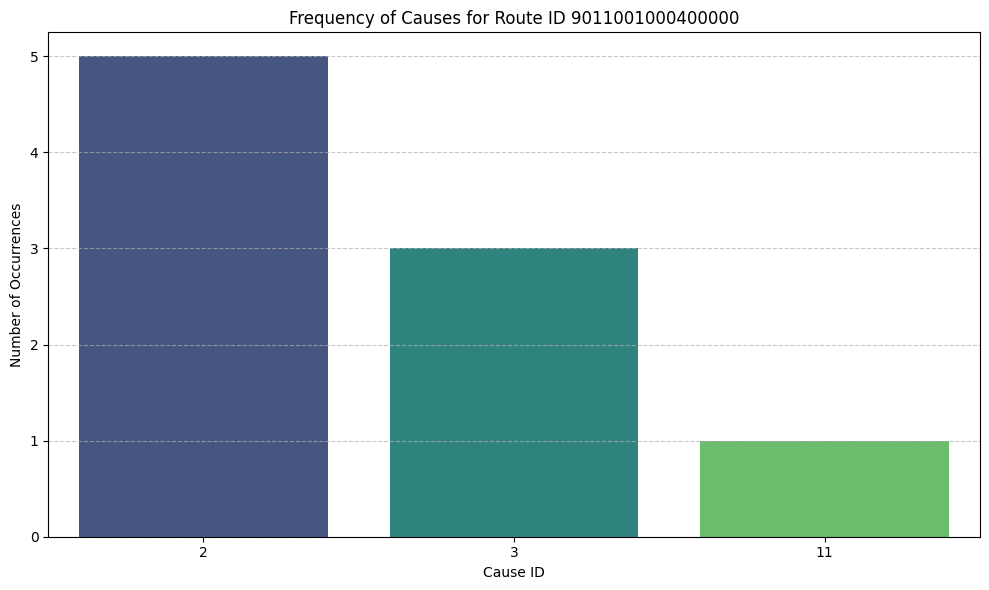

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the frequency of each cause for the target route_id
cause_frequency = rows_with_target_route_id['cause'].value_counts().reset_index()
cause_frequency.columns = ['Cause', 'Frequency']

# Create the bar plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Cause', y='Frequency', data=cause_frequency, palette='viridis')
plt.title(f'Frequency of Causes for Route ID {target_route_id}')
plt.xlabel('Cause ID')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [5]:
df['route_id'] = pd.to_numeric(df['route_id'], errors='coerce').astype('Int64') # Use 'Int64' to allow for pandas nullable integer type
print("Data type of 'route_id' column after conversion:")
display(df['route_id'].dtype)
print("First 10 unique values of 'route_id' column after conversion:")
display(df['route_id'].unique()[:10])

NameError: name 'df' is not defined

In [11]:
cause_distribution_all = df['cause'].value_counts().reset_index()
cause_distribution_all.columns = ['Cause', 'Count']

print("Distribution of all 'cause' IDs in the entire dataset:")
display(cause_distribution_all)

Distribution of all 'cause' IDs in the entire dataset:


,Cause,Count
0,2,1711317
1,3,222583
2,11,21844
3,12,5898
4,6,5449
5,9,4614
6,8,689
7,10,362
8,4,23


In [12]:
new_target_route_id = 9011001000300000
rows_with_new_target_route_id = df[df['route_id'] == new_target_route_id]

print(f"Number of rows where 'route_id' is {new_target_route_id}: {len(rows_with_new_target_route_id)}")

cause_frequency_new = rows_with_new_target_route_id['cause'].value_counts().reset_index()
cause_frequency_new.columns = ['Cause', 'Frequency']

print(f"Cause of delay for route_id {new_target_route_id}:")
display(cause_frequency_new)

Number of rows where 'route_id' is 9011001000300000: 30
Cause of delay for route_id 9011001000300000:


,Cause,Frequency
0,2,27
1,3,3


In [13]:
# Rename columns for clarity before combining
cause_frequency_original = cause_frequency.copy()
cause_frequency_original.columns = ['Cause', 'Frequency_9011001000400000']

cause_frequency_new.columns = ['Cause', 'Frequency_9011001000300000']

# Merge the two frequency dataframes
combined_cause_frequencies = pd.merge(
    cause_frequency_original,
    cause_frequency_new,
    on='Cause',
    how='outer'
).fillna(0)

display(combined_cause_frequencies)


,Cause,Frequency_9011001000400000,Frequency_9011001000300000
0,2,5,27.0
1,3,3,3.0
2,11,1,0.0


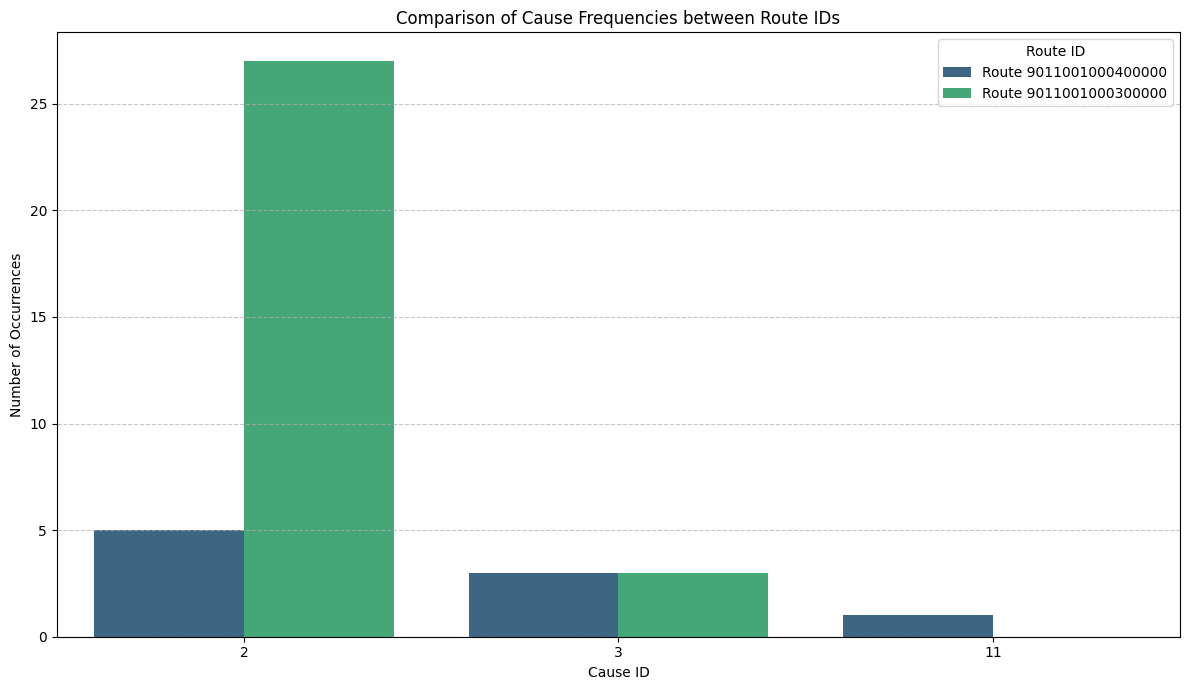

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
combined_plot_df = combined_cause_frequencies.melt(
    id_vars=['Cause'],
    var_name='Route ID',
    value_name='Frequency'
)

# Map the full route IDs to shorter names for better plot labels
route_id_mapping = {
    'Frequency_9011001000400000': 'Route 9011001000400000',
    'Frequency_9011001000300000': 'Route 9011001000300000'
}
combined_plot_df['Route ID'] = combined_plot_df['Route ID'].map(route_id_mapping)

fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Cause', y='Frequency', hue='Route ID', data=combined_plot_df, palette='viridis')
plt.title('Comparison of Cause Frequencies between Route IDs')
plt.xlabel('Cause ID')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.legend(title='Route ID')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
min_start_date = df['start'].min()
max_start_date = df['start'].max()
min_end_date = df['end'].min()
max_end_date = df['end'].max()

print(f"Minimum 'start' date: {min_start_date}")
print(f"Maximum 'start' date: {max_start_date}")
print(f"Minimum 'end' date: {min_end_date}")
print(f"Maximum 'end' date: {max_end_date}")

Minimum 'start' date: 2023-12-31 15:07:34
Maximum 'start' date: 2024-12-31 23:58:19
Minimum 'end' date: 2024-01-01 00:01:51
Maximum 'end' date: 2038-01-18 03:14:00


In [16]:
selected_cause_ids = [2, 3, 11, 12, 6, 9]

descriptions_for_selected_causes = df[df['cause'].isin(selected_cause_ids)].groupby('cause')['description_text2'].apply(lambda x: x.unique().tolist())

print("Unique descriptions for selected cause IDs:")
display(descriptions_for_selected_causes)

Unique descriptions for selected cause IDs:


,description_text2
cause,
2,"[Ingen pÃ¥stigning, Ingen påstigning, Se upp f..."
3,"[Försenad på grund av signalfel., Inställd del..."
6,"[Inställd avgång, Försenad avgång, Inställd av..."
9,"[Sprängningsarbeten vid Hökarängen, Stn.medd. ..."
11,[Försenad på grund av obehöriga i spårområdet....
12,"[Försenad avgång mot Akalla, Försenad avgång, ..."


In [17]:
# Ensure 'start' and 'end' columns are datetime objects
df['start'] = pd.to_datetime(df['start'])
df['end'] = pd.to_datetime(df['end'])

# Define the boundaries for the year 2024
start_of_2024 = pd.Timestamp('2024-01-01 00:00:00')
end_of_2024 = pd.Timestamp('2024-12-31 23:59:59')

# Filter the DataFrame for alerts active within 2024
df_2024 = df[(df['start'] <= end_of_2024) & (df['end'] >= start_of_2024)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape for alerts active in 2024: {df_2024.shape}")

print("First 5 rows of the 2024 filtered DataFrame:")
display(df_2024.head())

Original DataFrame shape: (1972779, 13)
Filtered DataFrame shape for alerts active in 2024: (1972779, 13)
First 5 rows of the 2024 filtered DataFrame:


,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp
0,14050001656394124,2024-01-06 05:06:14,2024-01-06 05:08:13,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001701003,2024-01-06 05:07:02.489510,20240106,None
1,14050001656394176,2024-01-06 05:06:47,2024-01-06 05:08:44,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001003481001,2024-01-06 05:07:02.489510,20240106,None
2,14050001656394207,2024-01-06 05:06:56,2024-01-06 05:08:55,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001551001,2024-01-06 05:08:02.602139,20240106,None
3,14050001656394246,2024-01-06 05:07:09,2024-01-06 05:09:08,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001831002,2024-01-06 05:08:02.602139,20240106,None
4,14050001656394262,2024-01-06 05:07:34,2024-01-06 05:09:34,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001002121002,2024-01-06 05:08:02.602139,20240106,None


In [6]:
target_route_id = 9011001000400000
rows_with_target_route_id = df[df['route_id'] == target_route_id]

description_by_cause = rows_with_target_route_id.groupby('cause')['description_text2'].apply(lambda x: x.unique().tolist())

print(f"Description text for each cause of route_id {target_route_id}:")
display(description_by_cause)

NameError: name 'df' is not defined

## Load and Inspect `routes.csv`

First, let's load the `routes.csv` file into a DataFrame and inspect its contents to understand its structure and how it relates to the `service_alerts` data.

In [20]:
routes_file_path = '/content/drive/MyDrive/routes.csv'

try:
    routes_df = pd.read_csv(routes_file_path, delimiter=';') # Specify semicolon as delimiter
    print('`routes.csv` loaded successfully!')
    display(routes_df.head())
    print(f"Data type of 'route_id' column in `routes_df`: {routes_df['route_id'].dtype}")
except FileNotFoundError:
    print(f"Error: The file at '{routes_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

`routes.csv` loaded successfully!


,route_id,route_short_name,route_long_name,route_type,route_desc
0,9011005090800000,908,NaN,700,NaN
1,9011008004100000,41,NaN,1000,Waxholmsbolaget
2,9011008003500000,35,NaN,1000,Waxholmsbolaget
3,9011005095200000,952,NaN,700,NaN
4,9011005095500000,955,NaN,700,NaN


Data type of 'route_id' column in `routes_df`: object


## Merging DataFrames

Both DataFrames, `df` (from `service_alerts_2024.parquet`) and `routes_df` (from `routes.csv`), contain a `route_id` column. We can use this common column to merge them, allowing you to enrich your service alerts data with route-specific information.

Since `route_id` in `df` is already converted to `Int64`, we should ensure the `route_id` in `routes_df` is also in a compatible format before merging.

In [21]:
# Convert 'route_id' in routes_df to a compatible numeric type, handling potential errors
routes_df['route_id'] = pd.to_numeric(routes_df['route_id'], errors='coerce').astype('Int64')

# Perform a left merge to add route information to the service alerts DataFrame
# We'll keep all service alerts and add route details where a match is found
merged_df = pd.merge(df_2024, routes_df, on='route_id', how='left', suffixes=('_alert', '_route'))

print("Merged DataFrame shape:", merged_df.shape)
print("First 5 rows of the merged DataFrame with route information:")
display(merged_df.head())

Merged DataFrame shape: (2522749, 17)
First 5 rows of the merged DataFrame with route information:


,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp,route_short_name,route_long_name,route_type,route_desc
0,14050001656394124,2024-01-06 05:06:14,2024-01-06 05:08:13,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001701003,2024-01-06 05:07:02.489510,20240106,None,NaN,NaN,NaN,NaN
1,14050001656394176,2024-01-06 05:06:47,2024-01-06 05:08:44,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001003481001,2024-01-06 05:07:02.489510,20240106,None,NaN,NaN,NaN,NaN
2,14050001656394207,2024-01-06 05:06:56,2024-01-06 05:08:55,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001551001,2024-01-06 05:08:02.602139,20240106,None,NaN,NaN,NaN,NaN
3,14050001656394246,2024-01-06 05:07:09,2024-01-06 05:09:08,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001831002,2024-01-06 05:08:02.602139,20240106,None,NaN,NaN,NaN,NaN
4,14050001656394262,2024-01-06 05:07:34,2024-01-06 05:09:34,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001002121002,2024-01-06 05:08:02.602139,20240106,None,NaN,NaN,NaN,NaN


## Route ID with Most Specific Cause IDs

Now that we have the `merged_df` containing both service alert and route information, let's identify which `route_id` has the most occurrences of the specified cause IDs (2, 3, 11, 12, 6, 9).

In [23]:
# Define the specific cause IDs to look for
specific_cause_ids = [2, 3, 11, 12, 6, 9]

# Filter the merged_df to include only these specific cause IDs
filtered_by_causes_df = merged_df[merged_df['cause'].isin(specific_cause_ids)]

# Exclude route_id = -1 from the analysis for a more meaningful result
filtered_by_causes_df = filtered_by_causes_df[filtered_by_causes_df['route_id'] != -1]

# Group by 'route_id' and count the total occurrences of these causes for each route
route_cause_counts = filtered_by_causes_df['route_id'].value_counts().reset_index()
route_cause_counts.columns = ['route_id', 'total_specific_cause_count']

# Sort in descending order to find the route with the most occurrences
most_impacted_route = route_cause_counts.sort_values(by='total_specific_cause_count', ascending=False)

print("Route IDs (excluding -1) with the most occurrences of specific cause IDs (2, 3, 11, 12, 6, 9):")
display(most_impacted_route.head(10))

# Display the top route ID
if not most_impacted_route.empty:
    top_route_id = most_impacted_route.iloc[0]['route_id']
    top_count = most_impacted_route.iloc[0]['total_specific_cause_count']
    print(f"\nThe route ID (excluding -1) with the most occurrences of these specific causes is: {top_route_id} with {top_count} total occurrences.")
else:
    print("\nNo routes found with the specified cause IDs (excluding -1).")

Route IDs (excluding -1) with the most occurrences of specific cause IDs (2, 3, 11, 12, 6, 9):


,route_id,total_specific_cause_count
0,9011001000700000,3545
1,9011001002100000,1468
2,9011001063900000,1246
3,9011001057400000,1163
4,9011001062600000,912
5,9011001062000000,729
6,9011001002700000,698
7,9011001062100000,541
8,9011001061000000,522
9,9011001002800000,506



The route ID (excluding -1) with the most occurrences of these specific causes is: 9011001000700000 with 3545 total occurrences.


In [24]:
selected_route_info = routes_df.iloc[[0, 1, 2, 3]][['route_short_name', 'route_long_name', 'route_type', 'route_desc']]
display(selected_route_info)

,route_short_name,route_long_name,route_type,route_desc
0,908,NaN,700,NaN
1,41,NaN,1000,Waxholmsbolaget
2,35,NaN,1000,Waxholmsbolaget
3,952,NaN,700,NaN


In [25]:
target_route_ids = [9011001000700000, 9011001002100000, 9011001063900000, 9011001057400000]
selected_route_names = routes_df[routes_df['route_id'].isin(target_route_ids)][['route_id', 'route_short_name']]
display(selected_route_names)

,route_id,route_short_name
66,9011001002100000,21
283,9011001057400000,574
337,9011001063900000,639
552,9011001000700000,7
